In [4]:
import librosa
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, Image
wav_path = 'resources/drum-sample-full.wav'
hpf_path = 'resources/drum-sample-hpf.wav'
from matplotlib.ticker import FuncFormatter, NullFormatter


# Original Drum Beat

In [5]:
y,sr = librosa.load(wav_path, sr=48000)

Audio(wav_path)

# HPF filtered

In [6]:
y_hpf,_ = librosa.load(hpf_path, sr=48000)

Audio(hpf_path)

# Used EQ

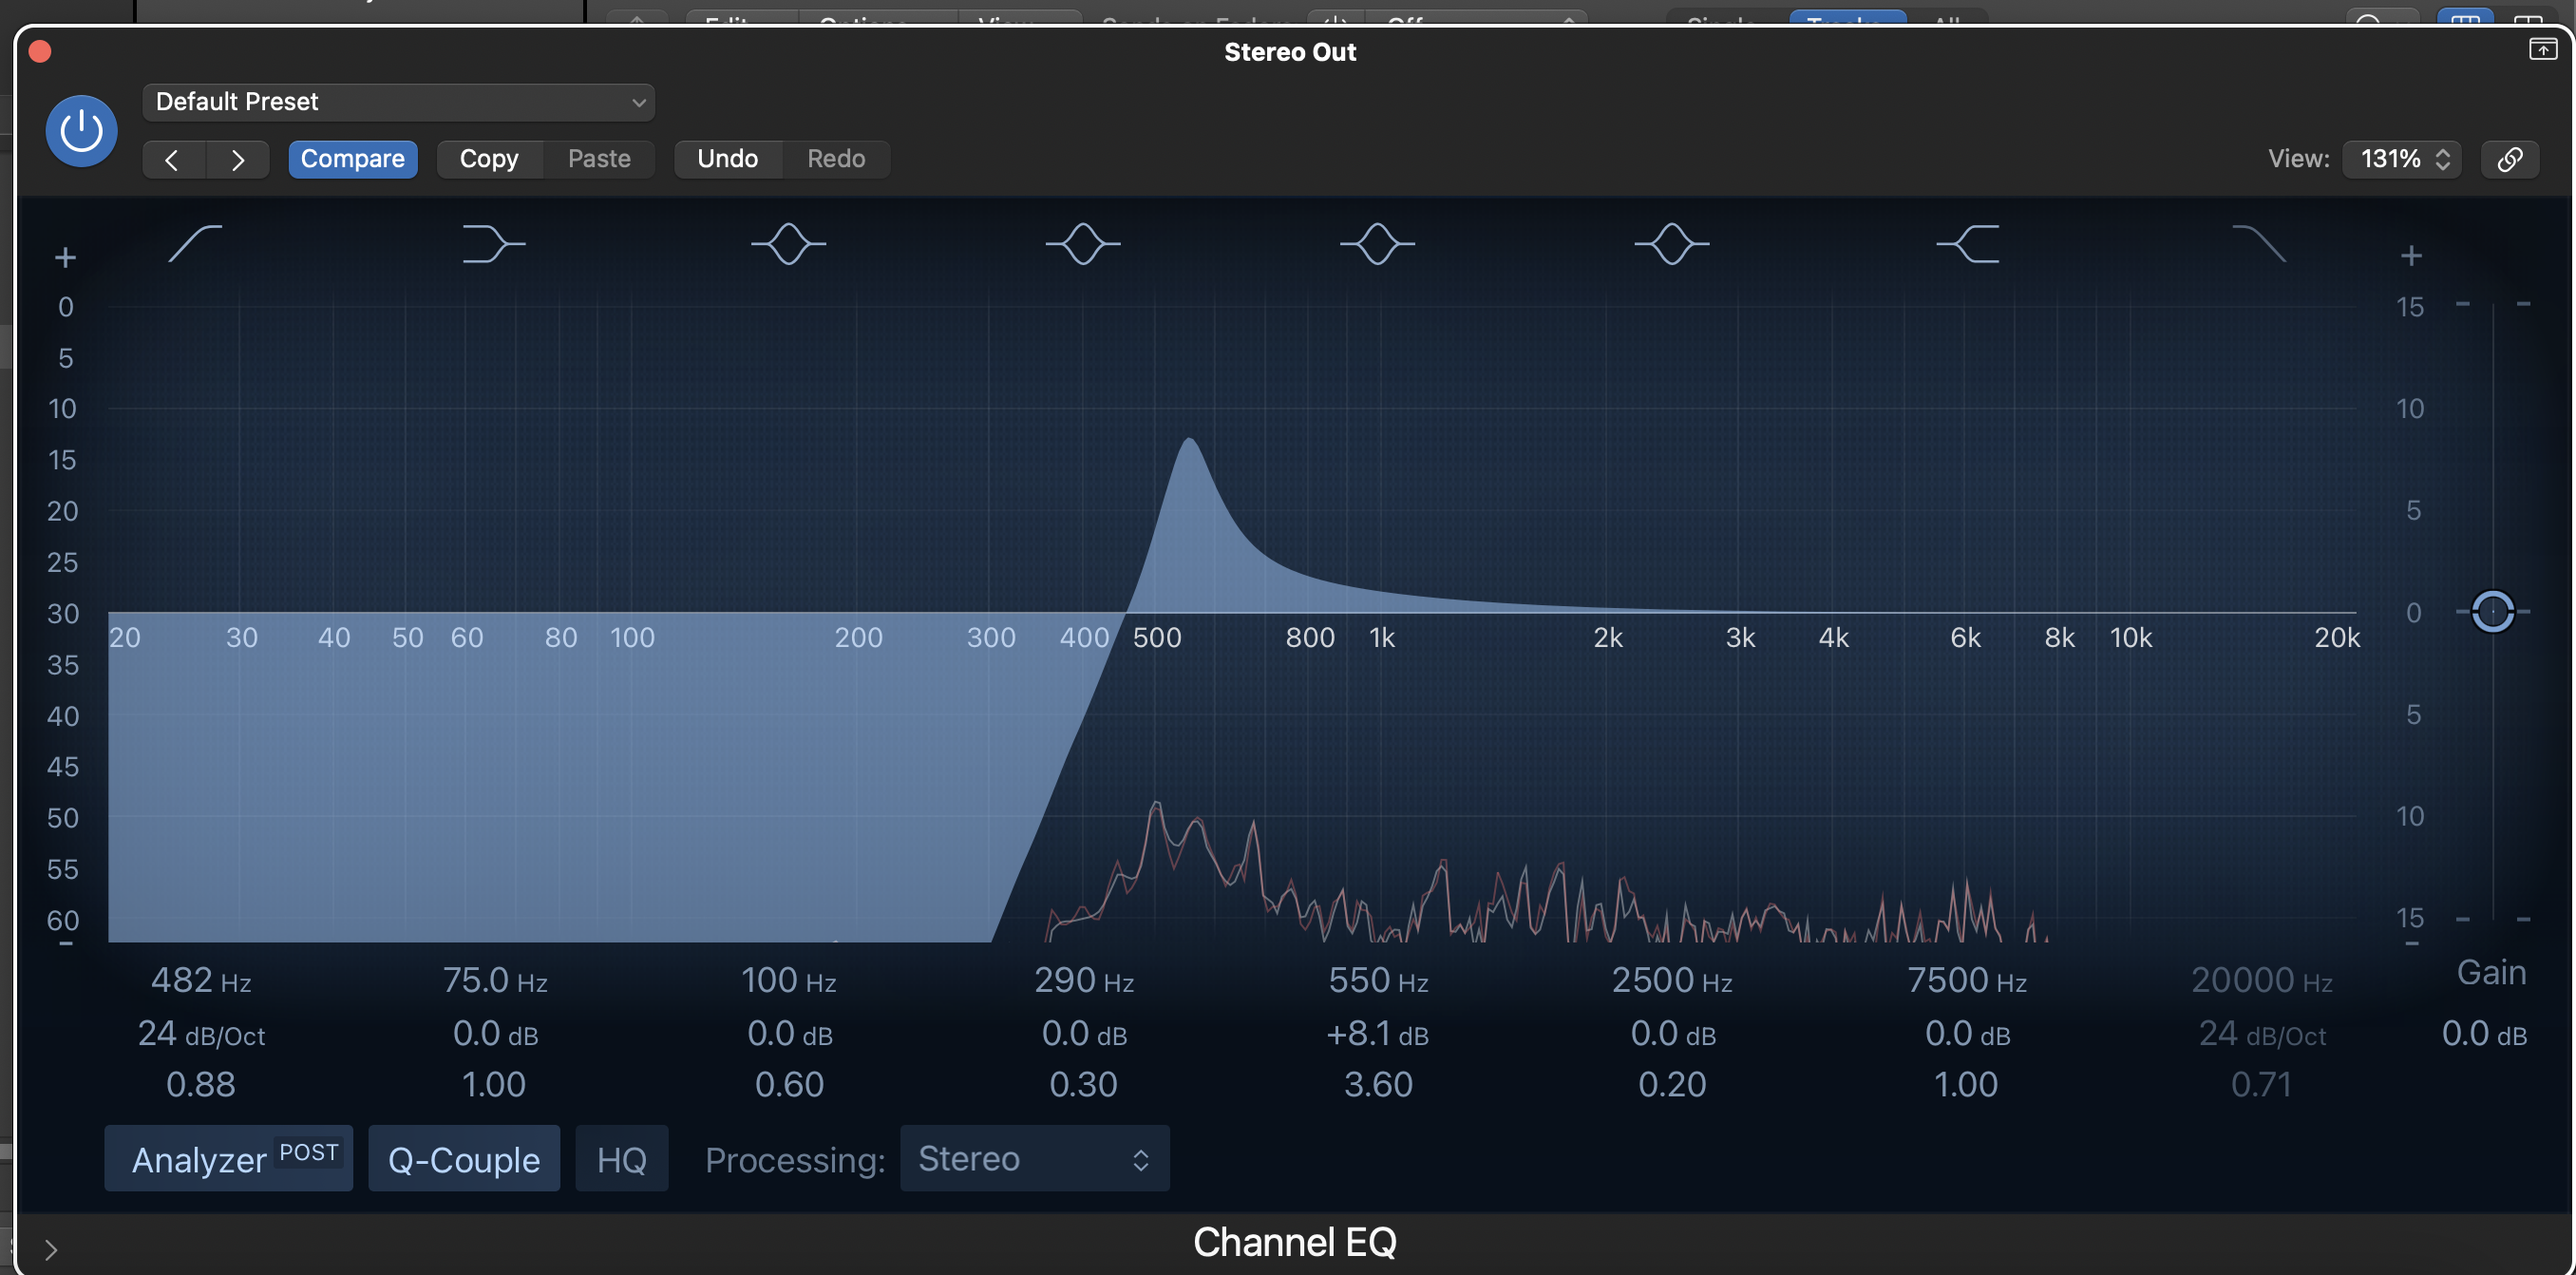

In [7]:
Image('image.png')

# Metadata

In [8]:
print("length in seconds",len(y)/sr)
print("y",len(y))
print("sr",sr)


length in seconds 4.0
y 192000
sr 48000


# Waveform

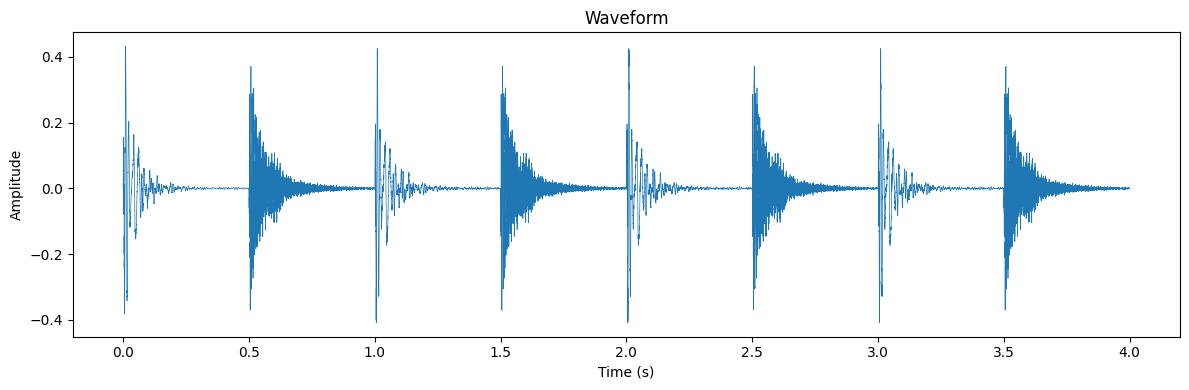

In [9]:
t = np.arange(len(y)) / sr          # or: np.linspace(0, len(y)/sr, len(y))

plt.figure(figsize=(12, 4))
plt.plot(t, y, linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.tight_layout()
plt.show()

# Spectograms

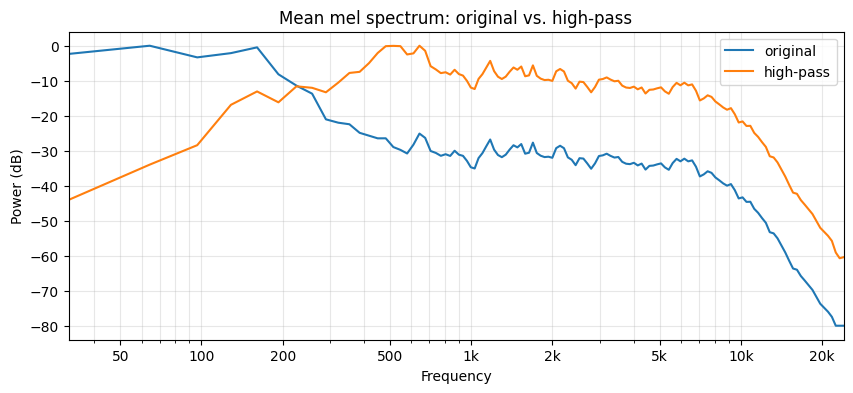

In [10]:
def mean_mel_db(sig, sr, n_mels=128, n_fft=2048, hop_length=512):
    S = librosa.feature.melspectrogram(
        y=sig, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmax=sr/2
    )
    return librosa.power_to_db(S.mean(axis=1), ref=np.max)

mel_freqs = librosa.mel_frequencies(n_mels=128, fmax=sr/2)

S_db     = mean_mel_db(y,     sr)
S_db_hpf = mean_mel_db(y_hpf, sr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mel_freqs, S_db,     label='original')
ax.plot(mel_freqs, S_db_hpf, label='high-pass')
ax.set(xlabel='Frequency', ylabel='Power (dB)',
       title='Mean mel spectrum: original vs. high-pass')
ax.set_xscale('log')

# explicit ticks at musically meaningful frequencies
ticks = [20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
ticks = [t for t in ticks if t <= sr/2]          # drop any above Nyquist
ax.set_xticks(ticks)

def hz_fmt(x, _):
    return f'{x/1000:g}k' if x >= 1000 else f'{x:g}'
ax.xaxis.set_major_formatter(FuncFormatter(hz_fmt))
ax.xaxis.set_minor_formatter(NullFormatter())    # suppress log minor-tick labels

ax.set_xlim(mel_freqs[mel_freqs > 0].min(), sr/2)
ax.grid(True, which='both', alpha=0.3)
ax.legend()

In [11]:
o_env = librosa.onset.onset_strength(y=y, sr=sr)
times = librosa.times_like(o_env, sr=sr)
onset_frames = librosa.onset.onset_detect(onset_envelope=o_env, sr=sr)

In [12]:
D = np.abs(librosa.stft(y))
np.shape(D)

(1025, 376)

In [13]:
df = pd.Series(times)
print(df)

0      0.000000
1      0.010667
2      0.021333
3      0.032000
4      0.042667
         ...   
371    3.957333
372    3.968000
373    3.978667
374    3.989333
375    4.000000
Length: 376, dtype: float64


In [14]:
df = pd.Series(onset_frames)
print(df)

0     48
1     95
2    141
3    188
4    235
5    282
6    329
dtype: int64


# Original Power spectrogram

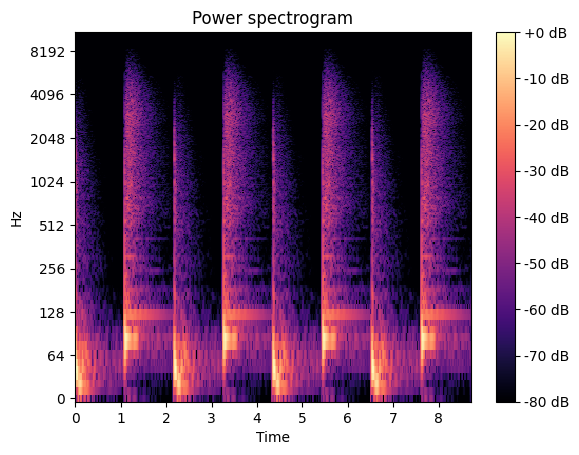

In [15]:
fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(D,
                                                       ref=np.max),
                               y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")

# HPF Power spectrogram

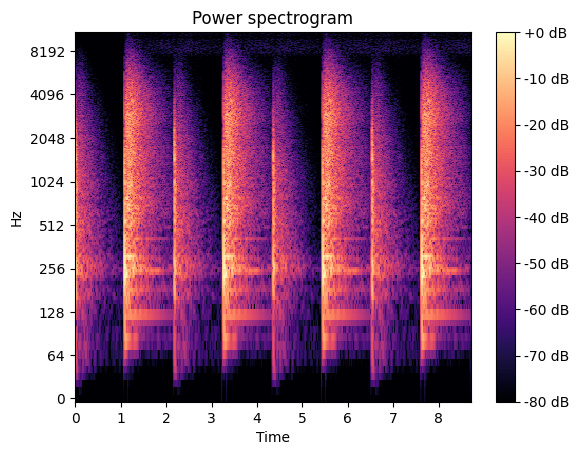

In [16]:
D_hpf = np.abs(librosa.stft(y_hpf))
np.shape(D)

fig, ax = plt.subplots()
img = librosa.display.specshow(librosa.amplitude_to_db(D_hpf,
                                                       ref=np.max),
                               y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")

# Onsets

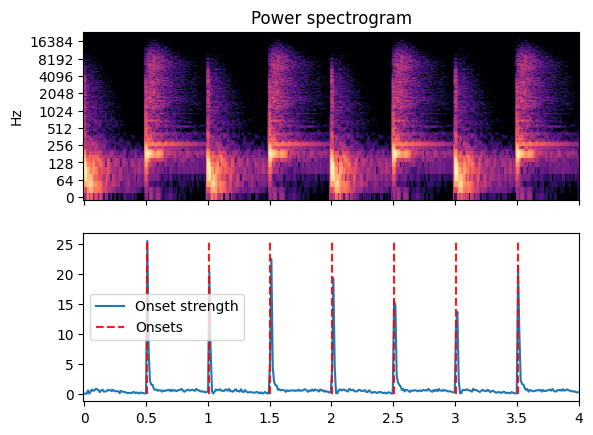

In [17]:
D = np.abs(librosa.stft(y))

fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max), x_axis='time', y_axis='log', ax=ax[0], sr=sr)
ax[0].set(title='Power spectrogram')
ax[0].label_outer()
ax[1].plot(times, o_env, label='Onset strength')
ax[1].vlines(times[onset_frames], 0, o_env.max(), color='r', alpha=0.9,
           linestyle='--', label='Onsets')
ax[1].legend()